# Exercise 6.6

### Importing libraries and data

In [1]:
import quandl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os
import warnings
warnings.filterwarnings("ignore")
plt.style.use('fivethirtyeight')

In [2]:
# Configure API key
quandl.ApiConfig.api_key = '6e7J7soMUuV5s2eoxNjK'

In [5]:
# Import Federal Reserve Economic Data "Natural Rate of Unemployment" variable.
data = quandl.get('FRED/NROU')

QuandlError: (Status 403) Something went wrong. Please try again. If you continue to have problems, please contact us at connect@quandl.com.

#### Imported Federal Reserve Economic Data " Total Vehicle Sales" variable

In [9]:
import pandas_datareader.data as web
import datetime
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2023, 1, 1)
df = web.DataReader('TOTALSA', 'fred', start, end)
print(df.head())

            TOTALSA
DATE               
2010-01-01   10.893
2010-02-01   10.315
2010-03-01   11.772
2010-04-01   11.454
2010-05-01   12.030


In [13]:
df.shape

(157, 1)

In [80]:
df.columns

Index(['TOTALSA'], dtype='object')

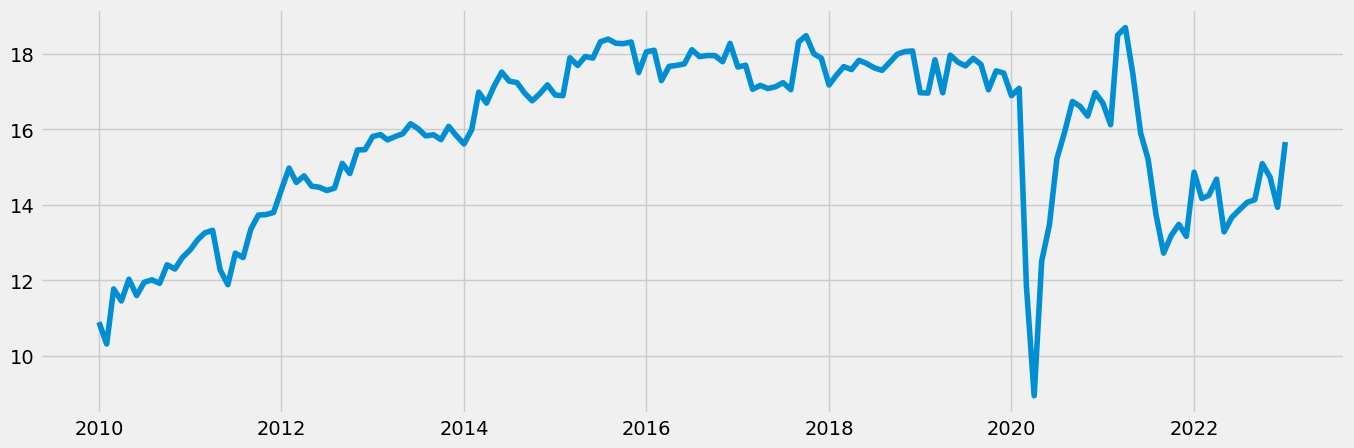

In [17]:
# Plot the data using matplotlib
plt.figure(figsize=(15,5), dpi=100)
plt.plot(df)

#### The data shows growth in total vehicle sales from 2010 - 2016 where it then levels off up until 2020 where we see a hugh delcine.  This was due to the COVID-19 pandemic. Although sales did recover, leading into 2022, there was were supply chain shortage of microchips, as well as rising interest rates and vehilce prices which lead to less conusmer demand.

#### Subsetting, wrangling, and cleaning time-series data

In [21]:
df1 = df.reset_index()

In [23]:
df1.head()

,DATE,TOTALSA
0,2010-01-01,10.893
1,2010-02-01,10.315
2,2010-03-01,11.772
3,2010-04-01,11.454
4,2010-05-01,12.030


In [25]:
df1.tail()

,DATE,TOTALSA
152,2022-09-01,14.136
153,2022-10-01,15.091
154,2022-11-01,14.733
155,2022-12-01,13.935
156,2023-01-01,15.665


In [37]:
df_sub = df1.loc[(df1['DATE'] >= '2016-01-01') & (df1['DATE'] < '2023-01-01')]

#### I decided to select data points between 2016 - 2023 as opposed to 2010 - 2023.  Total vheicle sales leveled off in 2016 so I wanted to focus on from that year on.

In [31]:
df_sub.head()

,DATE,TOTALSA
0,2010-01-01,10.893
1,2010-02-01,10.315
2,2010-03-01,11.772
3,2010-04-01,11.454
4,2010-05-01,12.030


In [39]:
# Set the "Date" column as the index
from datetime import datetime
df_sub['datetime'] = pd.to_datetime(df_sub['DATE'])
df_sub = df_sub.set_index('datetime')
df_sub.drop(['DATE'], axis=1, inplace=True)
df_sub.head()

,TOTALSA
datetime,
2016-01-01,18.054
2016-02-01,18.096
2016-03-01,17.291
2016-04-01,17.669
2016-05-01,17.695


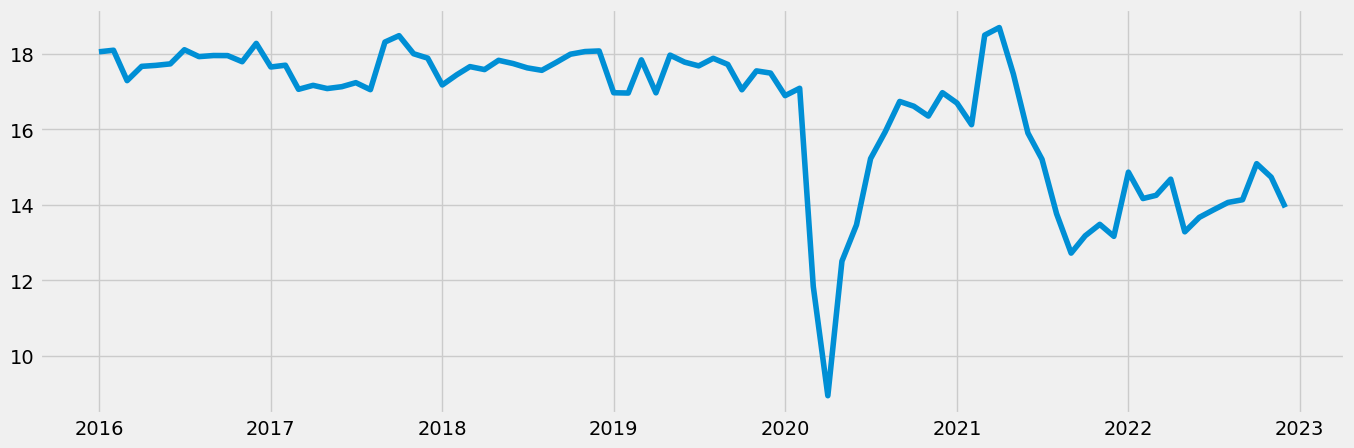

In [41]:
# Plot new data set
plt.figure(figsize=(15,5), dpi=100)
plt.plot(df_sub)

In [45]:
# Check for missing values
df_sub.isnull().sum()

TOTALSA    0
dtype: int64

In [47]:
# Check for dupicates
dups = df_sub.duplicated()
dups.sum()

0

#### Time-series analysis: decomposition

In [50]:
# Decompose the time series using an additive model
decomposition = sm.tsa.seasonal_decompose(df_sub, model='additive')

In [52]:
from pylab import rcParams
rcParams['figure.figsize'] = 18, 7

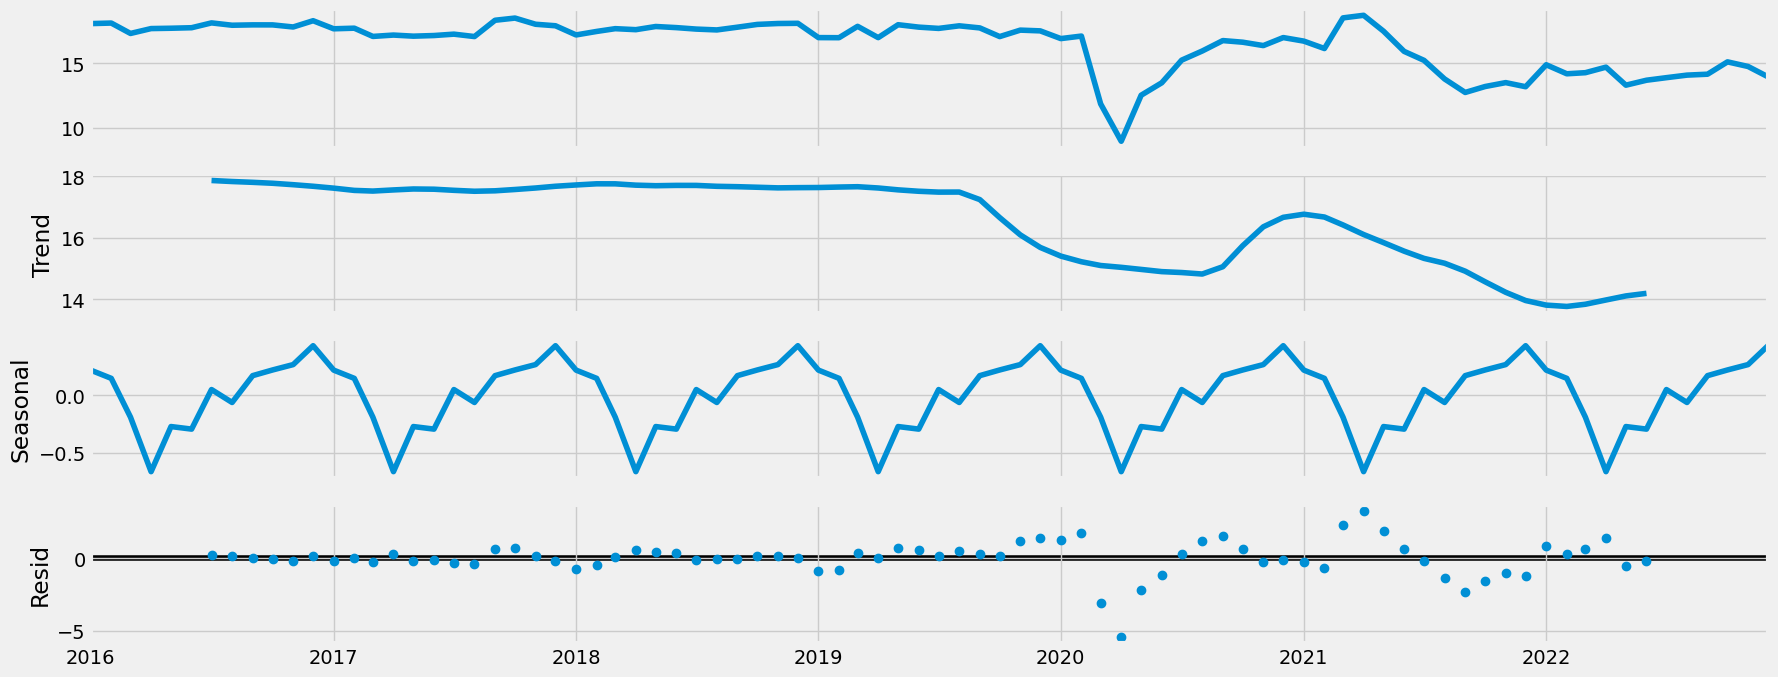

In [54]:
# Plot the separate components
decomposition.plot()
plt.show()

#### Because the level and Trend lines differ is would mean that this is unsmoothed data or does contain some noise. The seasonal line clearly shows seasonal fluctuations as it demonstates regular intervals each year.  On the residual line, which represents the noice within the data, we clearly see there isn't much unexplained noise up until 2020 where it shows where we start to see up and down deviations.  The noise in question is mostly due to COVID-19 in 2020 and a microchip shortage and higher vehicle prices in 2021 leading into 2023.

#### Testing for stationarity


In [61]:
from statsmodels.tsa.stattools import adfuller
def dickey_fuller(timeseries):
    print ('Dickey-Fuller Stationsarity test:')
    test = adfuller(timeseries, autolag='AIC')
    result = pd.Series(test[0:4], index=['Test Statistic', 'p-value', 'Number of Lags Used', 'Number of Observations Used'])
    for key,value in test[4].items():
        result['Critical Value (%s) '%key] = value
    print (result)

dickey_fuller(df_sub['TOTALSA'])

Dickey-Fuller Stationsarity test:
Test Statistic                 -2.737870
p-value                         0.067711
Number of Lags Used             1.000000
Number of Observations Used    82.000000
Critical Value (1%)            -3.512738
Critical Value (5%)            -2.897490
Critical Value (10%)           -2.585949
dtype: float64


Using a signifiance level of 5, the Critical Value (5%) is smaller than the Test Statistic, would means I can't reject the null hypothesis. 

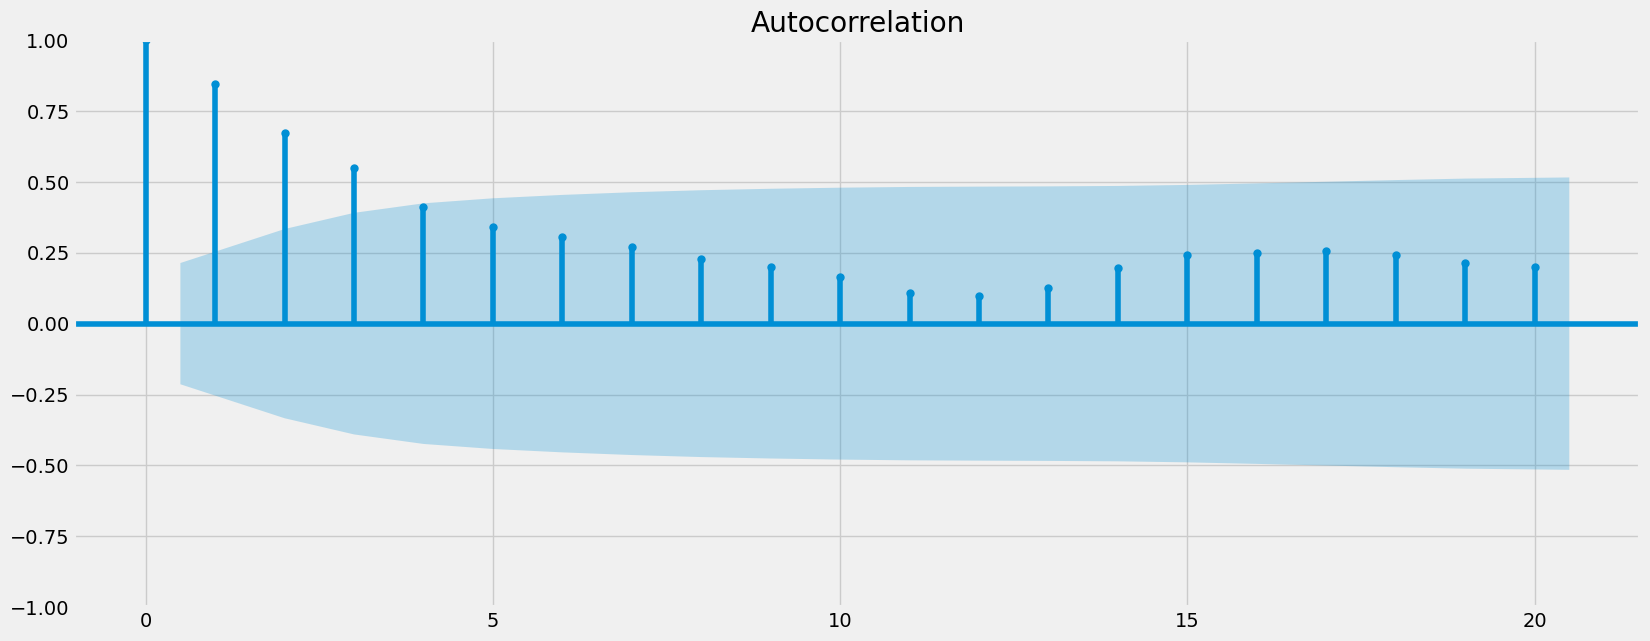

In [63]:
# Check out a plot of autocorreclations
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df_sub)
plt.show()